In [19]:
import yfinance as yf
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
import matplotlib.pyplot as plt


In [4]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2018-01-01",
    end="2023-01-01",
    interval="1d"
)


# Séparer prix et volume
price_df = data["Close"]
volume_df = data["Volume"]

print(price_df.head())
print(volume_df.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN      GOOGL       MSFT      NVDA
Date                                                            
2018-01-02  40.304188  59.450500  53.220631  78.870369  4.928266
2018-01-03  40.297153  60.209999  54.128628  79.237427  5.252614
2018-01-04  40.484337  60.479500  54.338890  79.934822  5.280302
2018-01-05  40.945267  61.457001  55.059433  80.925850  5.325049
2018-01-08  40.793190  62.343498  55.253830  81.008446  5.488213
Ticker           AAPL      AMZN     GOOGL      MSFT       NVDA
Date                                                          
2018-01-02  102223600  53890000  31766000  22483800  355616000
2018-01-03  118071600  62176000  31318000  26061400  914704000
2018-01-04   89738400  60442000  26052000  21912000  583268000
2018-01-05   94640000  70894000  30250000  23407100  580124000
2018-01-08   82271200  85590000  24644000  22113000  881216000


In [5]:
def prepare_features(price_df: pd.DataFrame, volume_df: pd.DataFrame):
    """
    price_df  : DataFrame index=date, columns=tickers, values=close
    volume_df : DataFrame index=date, columns=tickers, values=volume

    Retourne un DataFrame multi-index colonnes:
    (ticker, feature)
    """
    tickers = list(price_df.columns)

    feats = {}
    for t in tickers:
        px = price_df[t].copy()
        vol = volume_df[t].copy()

        df_t = pd.DataFrame(index=price_df.index)
        df_t["close"] = px
        df_t["ret_1"] = px.pct_change(1)
        df_t["ret_5"] = px.pct_change(5)
        df_t["vol_20"] = px.pct_change().rolling(20).std() * np.sqrt(252)

        vol_mean = vol.rolling(20).mean()
        vol_std = vol.rolling(20).std()
        df_t["vol_z"] = (vol - vol_mean) / (vol_std + 1e-8)

        feats[t] = df_t

    panel = pd.concat(feats, axis=1)
    panel = panel.dropna().copy()
    return panel

In [6]:
prepare_features(price_df, volume_df).head()

AAPL                                               AMZN  \
                close     ret_1     ret_5    vol_20     vol_z      close   
Date                                                                       
2018-01-31  39.174076  0.002754 -0.038974  0.150197  0.079854  72.544502   
2018-02-01  39.255962  0.002090 -0.019462  0.150652  1.426954  69.500000   
2018-02-02  37.552658 -0.043390 -0.064194  0.210328  3.262015  71.497498   
2018-02-05  36.614418 -0.024985 -0.068290  0.215368  1.990362  69.500000   
2018-02-06  38.144604  0.041792 -0.023598  0.273154  1.531135  72.141998   

                                                    ...       MSFT            \
               ret_1     ret_5    vol_20     vol_z  ...      close     ret_1   
Date                                                ...                        
2018-01-31  0.009090  0.068788  0.155874  1.330957  ...  87.184090  0.024477   
2018-02-01 -0.041967  0.008745  0.241030  2.602393  ...  86.495880 -0.007894   
2018-02-02  0.028741  0.019899  0.252368  2.823383  ...  84.220169 -0.026310   
2018-02-05 -0.027938 -0.019525  0.281529  2.381581  ...  80.751518 -0.041186   
2018-02-06  0.038014  0.003491  0.302229  1.871241  ...  83.807182  0.037840   

                                              NVDA                      \
               ret_5    vol_20     vol_z     close     ret_1     ret_5   
Date                                                                     
2018-01-31  0.034742  0.168650  2.694147  6.076590  0.012690  0.042409   
2018-02-01  0.020903  0.174835  2.068007  5.945564 -0.021562  0.017559   
2018-02-02 -0.024240  0.205054  1.829137  5.773006 -0.029023 -0.040316   
2018-02-05 -0.063032  0.253832  1.836289  5.283024 -0.084875 -0.134292   
2018-02-06 -0.015204  0.287220  2.591862  5.576716  0.055592 -0.070616   

                                
              vol_20     vol_z  
Date                            
2018-01-31  0.301491 -0.531187  
2018-02-01  0.243600 -0.137660  
2018-02-02  0.274080  1.433055  
2018-02-05  0.418750  3.191938  
2018-02-06  0.451124  2.507944  

[5 rows x 25 columns]

In [7]:
class MultiAssetTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        features_panel,
        tickers,
        initial_cash=100000.0,
        transaction_cost=0.001,
        max_steps=252
    ):
        super().__init__()

        self.data = features_panel.copy()
        self.tickers = list(tickers)
        self.n_assets = len(self.tickers)
        self.initial_cash = float(initial_cash)
        self.transaction_cost = float(transaction_cost)
        self.max_steps = int(max_steps)

        # Features par actif
        self.asset_features = ["ret_1", "ret_5", "vol_20", "vol_z"]
        self.n_features_per_asset = len(self.asset_features)

        # Observation = features multi-actifs + poids actuels + cash ratio
        self.obs_dim = self.n_assets * self.n_features_per_asset + self.n_assets + 1

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32
        )

        # Action globale discrète = produit cartésien des actions par actif
        # 0=HOLD, 1=BUY, 2=SELL pour chaque actif
        self.action_space = spaces.Discrete(3 ** self.n_assets)

        self.dates = self.data.index.unique().tolist()
        self._reset_internal_state()

    def _reset_internal_state(self):
        self.current_step = 0
        self.start_step = 0
        self.end_step = min(len(self.dates) - 2, self.max_steps)

        self.cash = self.initial_cash
        self.weights = np.zeros(self.n_assets, dtype=np.float64)
        self.portfolio_value = self.initial_cash
        self.portfolio_values = [self.initial_cash]
        self.n_trades = 0

    def _decode_action(self, action_int):
        # transforme un entier en vecteur base-3 de taille n_assets
        acts = []
        x = int(action_int)
        for _ in range(self.n_assets):
            acts.append(x % 3)
            x //= 3
        return np.array(acts, dtype=np.int64)

    def _get_prices(self, step):
        date = self.dates[step]
        return np.array([self.data.loc[date, (t, "close")] for t in self.tickers], dtype=np.float64)

    def _get_feature_vector(self, step):
        date = self.dates[step]
        feats = []
        for t in self.tickers:
            for f in self.asset_features:
                feats.append(self.data.loc[date, (t, f)])
        feats = np.array(feats, dtype=np.float32)

        cash_ratio = np.array([self.cash / max(self.portfolio_value, 1e-8)], dtype=np.float32)
        weights = self.weights.astype(np.float32)

        obs = np.concatenate([feats, weights, cash_ratio], axis=0)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_internal_state()
        obs = self._get_feature_vector(self.current_step)
        info = {"portfolio_value": self.portfolio_value}
        return obs, info

    def step(self, action):
        action_vec = self._decode_action(action)

        prices_t = self._get_prices(self.current_step)
        old_value = self.portfolio_value

        # Cible simple : BUY => actif éligible pour poids égal
        # SELL => poids 0
        # HOLD => on garde le poids actuel
        target_weights = self.weights.copy()

        for i, a in enumerate(action_vec):
            if a == 1:      # BUY
                target_weights[i] = 1.0
            elif a == 2:    # SELL
                target_weights[i] = 0.0

        # normalisation en poids égaux parmi les actifs "achetés"
        if target_weights.sum() > 0:
            target_weights = (target_weights > 0).astype(np.float64)
            target_weights /= target_weights.sum()
        else:
            target_weights = np.zeros_like(target_weights)

        turnover = np.abs(target_weights - self.weights).sum()
        trading_cost = turnover * self.transaction_cost * old_value

        # passage au jour suivant
        self.current_step += 1
        prices_tp1 = self._get_prices(self.current_step)

        asset_returns = (prices_tp1 / prices_t) - 1.0
        gross_portfolio_return = np.dot(target_weights, asset_returns)

        new_value = old_value * (1.0 + gross_portfolio_return) - trading_cost
        new_value = max(new_value, 1e-8)

        self.weights = target_weights
        self.portfolio_value = new_value
        self.cash = new_value * (1.0 - self.weights.sum())  # ici souvent 0 si investi
        self.portfolio_values.append(new_value)

        if turnover > 0:
            self.n_trades += 1

        # reward simple
        reward = (new_value - old_value) / old_value

        terminated = bool(new_value <= self.initial_cash * 0.5)
        truncated = bool(self.current_step >= self.end_step)

        obs = self._get_feature_vector(self.current_step)
        info = {
            "portfolio_value": float(new_value),
            "daily_return": float(reward),
            "turnover": float(turnover),
            "n_trades": int(self.n_trades),
            "weights": self.weights.copy()
        }
        return obs, float(reward), terminated, truncated, info

    def get_metrics(self):
        values = np.array(self.portfolio_values, dtype=np.float64)
        rets = pd.Series(values).pct_change().dropna().values

        total_return = values[-1] / values[0] - 1.0
        sharpe = 0.0
        if len(rets) > 1 and np.std(rets) > 1e-12:
            sharpe = (np.mean(rets) / np.std(rets)) * np.sqrt(252)

        running_max = np.maximum.accumulate(values)
        drawdowns = values / running_max - 1.0
        max_drawdown = float(drawdowns.min())

        return {
            "total_return": float(total_return),
            "sharpe": float(sharpe),
            "max_drawdown": max_drawdown,
            "n_trades": int(self.n_trades)
        }

In [8]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    max_steps=252
)


check_env(env, warn=True)
print("Environnement valide pour SB3.")

Environnement valide pour SB3.


In [ ]:
def make_env():
    return MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        max_steps=252
    )

train_env = DummyVecEnv([make_env])
train_env = VecMonitor(train_env)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    verbose=1,
    seed=42
)

model.learn(total_timesteps=200_000)

In [ ]:
model.save("ppo_multiasset_discrete")

In [11]:
model = PPO.load("ppo_multiasset_discrete")

In [9]:
def equal_weight_buy_and_hold(price_df, tickers):
    px = price_df[tickers].copy().dropna()
    daily_returns = px.pct_change().dropna()
    ew_returns = daily_returns.mean(axis=1)


    total_return = (1 + ew_returns).prod() - 1
    sharpe = 0.0
    if ew_returns.std() > 1e-12:
        sharpe = ew_returns.mean() / ew_returns.std() * np.sqrt(252)

    equity = (1 + ew_returns).cumprod()
    dd = equity / equity.cummax() - 1
    max_drawdown = dd.min()

    return {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown)
    }

baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers)
print(baseline)

{'total_return': 1.2561203167358888, 'sharpe': 0.6757995234429832, 'max_drawdown': -0.41539158978665847}


In [10]:
def evaluate_trained_model(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

        rewards.append(reward)
        portfolio_values.append(info["portfolio_value"])

    values = np.array(portfolio_values, dtype=np.float64)
    returns = pd.Series(values).pct_change().dropna()

    total_return = values[-1] / values[0] - 1.0

    sharpe = 0.0
    if returns.std() > 1e-12:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    running_max = np.maximum.accumulate(values)
    drawdowns = values / running_max - 1.0
    max_drawdown = drawdowns.min()

    results = {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown),
        "final_portfolio_value": float(values[-1]),
        "avg_reward": float(np.mean(rewards)) if len(rewards) > 0 else 0.0,
        "n_steps": len(rewards),
        "n_trades": info.get("n_trades", None),
        "portfolio_values": values
    }

    return results

## Test du model sur données jamais vue

In [13]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2023-01-01",
    end="2023-07-01",
    interval="1d"
)


# Séparer prix et volume
price_df = data["Close"]
volume_df = data["Volume"]

print(price_df.head())
print(volume_df.head())

[*********************100%***********************]  5 of 5 completed

Ticker            AAPL       AMZN      GOOGL        MSFT       NVDA
Date                                                               
2023-01-03  123.096016  85.820000  88.389473  233.452774  14.299909
2023-01-04  124.365654  85.139999  87.357979  223.240845  14.733452
2023-01-05  123.046829  83.120003  85.493393  216.624466  14.249964
2023-01-06  127.574203  86.080002  86.624054  219.177460  14.843337
2023-01-09  128.095840  87.360001  87.298462  221.311478  15.611526
Ticker           AAPL      AMZN     GOOGL      MSFT       NVDA
Date                                                          
2023-01-03  112117500  76706000  28131200  25740000  401277000
2023-01-04   89113600  68885100  34854800  50623400  431324000
2023-01-05   80962700  67930800  27194400  39585600  389168000
2023-01-06   87754700  83303400  41381500  43613600  405044000
2023-01-09   70790800  65266100  29003900  27369800  504231000


In [15]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

In [16]:
test_env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    max_steps=252
)

results = evaluate_trained_model(model, test_env)

print("Résultats du modèle :")
print(f"Total Return     : {results['total_return']:.2%}")
print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
print(f"Nombre de trades : {results['n_trades']}")

Résultats du modèle :
Total Return     : 19.57%
Sharpe Ratio     : 1.721
Max Drawdown     : -6.70%
Valeur finale    : 119570.75
Nombre de trades : 62


In [17]:
baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers)

print("Baseline :")
print(f"Total Return : {baseline['total_return']:.2%}")
print(f"Sharpe       : {baseline['sharpe']:.3f}")
print(f"Max DD       : {baseline['max_drawdown']:.2%}")

Baseline :
Total Return : 41.94%
Sharpe       : 3.354
Max DD       : -8.33%


In [18]:
print("Comparaison IA vs baseline")
print(f"Surperformance return : {results['total_return'] - baseline['total_return']:.2%}")
print(f"Différence Sharpe     : {results['sharpe'] - baseline['sharpe']:.3f}")

Comparaison IA vs baseline
Surperformance return : -22.37%
Différence Sharpe     : -1.633


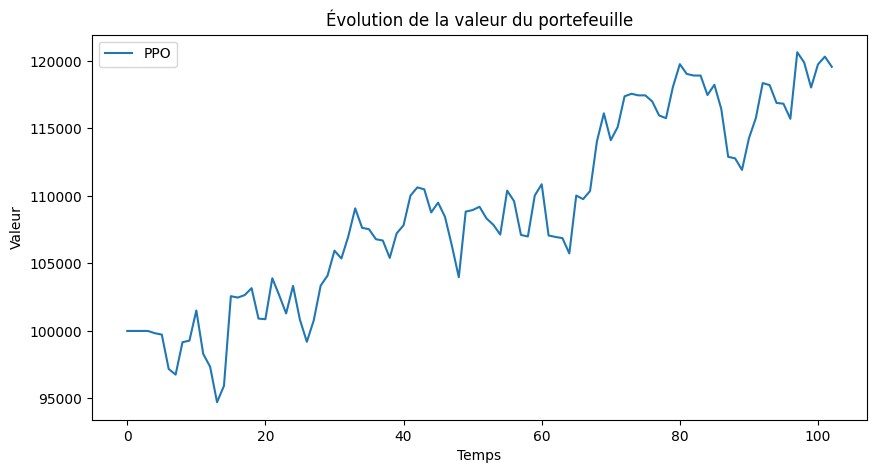

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(results["portfolio_values"], label="PPO")
plt.title("Évolution de la valeur du portefeuille")
plt.xlabel("Temps")
plt.ylabel("Valeur")
plt.legend()
plt.show()

In [21]:
def get_ppo_portfolio_curve(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    dates = [env.dates[env.current_step]]

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

        portfolio_values.append(info["portfolio_value"])
        dates.append(env.dates[env.current_step])

    curve = pd.DataFrame({
        "date": dates,
        "ppo_portfolio": portfolio_values
    }).set_index("date")

    return curve

In [22]:
def get_buy_and_hold_curve(price_df, tickers, initial_cash=100000):
    px = price_df[tickers].copy().dropna()

    # Prix initiaux
    first_prices = px.iloc[0]

    # Capital réparti également
    alloc_per_asset = initial_cash / len(tickers)

    # Nombre de parts achetées au départ
    shares = alloc_per_asset / first_prices

    # Valeur du portefeuille au fil du temps
    portfolio_values = (px * shares).sum(axis=1)

    curve = pd.DataFrame({
        "buy_hold_portfolio": portfolio_values
    })

    return curve

In [23]:
test_prices = price_df.loc[panel.index, tickers].copy()

In [25]:
ppo_curve = get_ppo_portfolio_curve(model, test_env)
bh_curve = get_buy_and_hold_curve(test_prices, tickers, initial_cash=100000)

In [26]:
comparison = ppo_curve.join(bh_curve, how="inner")
print(comparison.head())

            ppo_portfolio  buy_hold_portfolio
2023-02-01  100000.000000       100000.000000
2023-02-02  100000.000000       105342.171995
2023-02-03  100000.000000       102371.906042
2023-02-06  100000.000000       101250.898815
2023-02-07   99831.493742       104472.091534


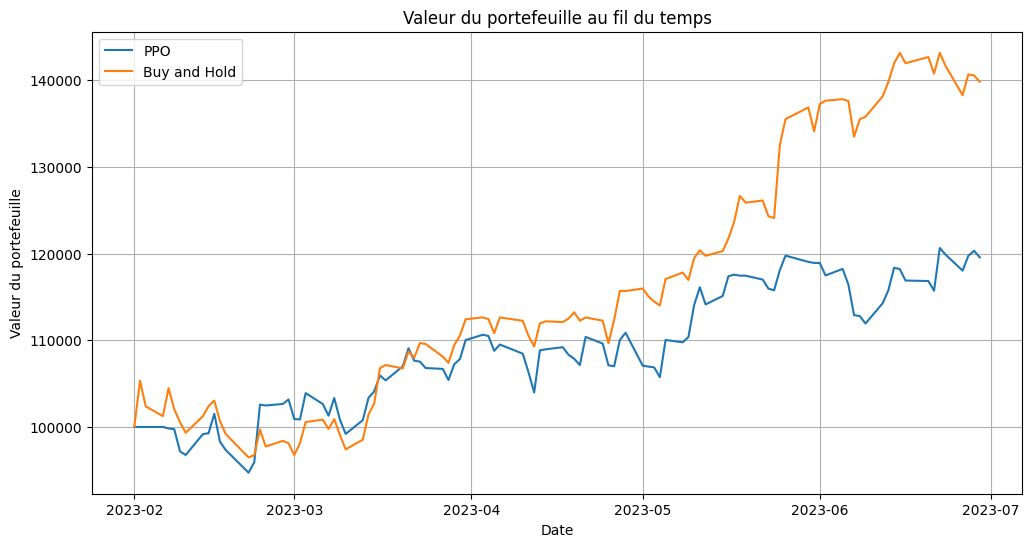

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison["ppo_portfolio"], label="PPO")
plt.plot(comparison.index, comparison["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Valeur du portefeuille au fil du temps")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()